### Synthetic Data Generation 

In [4]:
import numpy as np
import pandas as pd 


In [5]:
np.random.seed(42)

n_loans = 5000

data = pd.DataFrame({
    "Loan_ID": np.arange(1, n_loans+1),
    
    "Loan_Amount": np.random.normal(250000, 100000, n_loans).clip(80000,800000),
    
    "Property_Value": np.random.normal(320000,120000,n_loans).clip(100000,1000000),
    
    "FICO": np.random.normal(700,60,n_loans).clip(580,820),
    
    "DTI": np.random.normal(0.32,0.08,n_loans).clip(0.15,0.50),
    
    "Interest_Rate": np.random.normal(0.055,0.01,n_loans).clip(0.03,0.08),
    
    "Income": np.random.normal(90000,30000,n_loans).clip(40000,200000),
    
    "Employment_Status": np.random.binomial(1,0.95,n_loans),
    
    "Region": np.random.choice(["West","Midwest","South","Northeast"], n_loans)
})

# Calculate LTV
data["LTV"] = data["Loan_Amount"]/data["Property_Value"]

# Baseline Probability of Default
data["PD_base"] = (
    0.02
    + 0.04*(data["DTI"]-0.3)
    + 0.03*(data["LTV"]-0.8)
    - 0.00005*(data["FICO"]-700)
)

data["PD_base"] = data["PD_base"].clip(0.005,0.08)

# Loss Given Default
data["LGD"] = 0.1 + 0.35*(data["LTV"]-0.6)
data["LGD"] = data["LGD"].clip(0.1,0.45)

print(data.head())

   Loan_ID    Loan_Amount  Property_Value        FICO       DTI  \
0        1  299671.415301   269148.838157  659.290316  0.308526   
1        2  236173.569883   265590.306994  681.670032  0.317388   
2        3  314768.853810   104522.819284  664.157136  0.325144   
3        4  402302.985641   280389.176996  706.625083  0.395749   
4        5  226584.662528   407939.489819  771.830712  0.260223   

   Interest_Rate         Income  Employment_Status     Region       LTV  \
0       0.058483   95126.205862                  1  Northeast  1.113404   
1       0.057833   90367.662919                  1  Northeast  0.889240   
2       0.045635   77065.348007                  1  Northeast  3.011485   
3       0.060796   89924.200175                  1    Midwest  1.434802   
4       0.040099  104725.248765                  1       West  0.555437   

    PD_base       LGD  
0  0.031779  0.279691  
1  0.024289  0.201234  
2  0.080000  0.450000  
3  0.042543  0.392181  
4  0.007480  0.100000  


### Makes the data realistic by limiting the occurence of UNREALISTIC numbers

* .clip(lower_linit,upper_limit)  forces the generated number to be reasonable within the bound otherwise it will be too high or too low 
* for eg the real FICO score ranges between (580,820) for REAL borrowers



In [6]:
data.head()

,Loan_ID,Loan_Amount,Property_Value,FICO,DTI,Interest_Rate,Income,Employment_Status,Region,LTV,PD_base,LGD
0,1,299671.415301,269148.838157,659.290316,0.308526,0.058483,95126.205862,1,Northeast,1.113404,0.031779,0.279691
1,2,236173.569883,265590.306994,681.670032,0.317388,0.057833,90367.662919,1,Northeast,0.889240,0.024289,0.201234
2,3,314768.853810,104522.819284,664.157136,0.325144,0.045635,77065.348007,1,Northeast,3.011485,0.080000,0.450000
3,4,402302.985641,280389.176996,706.625083,0.395749,0.060796,89924.200175,1,Midwest,1.434802,0.042543,0.392181
4,5,226584.662528,407939.489819,771.830712,0.260223,0.040099,104725.248765,1,West,0.555437,0.007480,0.100000


In [7]:
data.describe()

,Loan_ID,Loan_Amount,Property_Value,FICO,DTI,Interest_Rate,Income,Employment_Status,LTV,PD_base,LGD
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,252437.686429,320430.287643,700.669991,0.321514,0.054823,90363.428530,0.949600,0.939783,0.024843,0.211376
std,1443.520003,95652.124671,117655.495292,57.257428,0.077914,0.009749,28827.899694,0.218791,0.619209,0.017154,0.123374
min,1.000000,80000.000000,100000.000000,580.000000,0.150000,0.030000,40000.000000,0.000000,0.117797,0.005000,0.100000
25%,1250.750000,184209.496234,237610.051926,660.346818,0.266826,0.047982,69023.236876,1.000000,0.536447,0.012692,0.100000
50%,2500.500000,251346.559190,317905.936910,700.595047,0.321541,0.054920,89968.713185,1.000000,0.787830,0.020692,0.165740
75%,3750.250000,316601.060705,401268.567891,740.532055,0.376529,0.061506,110323.250858,1.000000,1.146612,0.031858,0.291314
max,5000.000000,642623.770644,743486.622508,820.000000,0.500000,0.080000,200000.000000,1.000000,5.609919,0.080000,0.450000


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            5000 non-null   int64  
 1   Loan_Amount        5000 non-null   float64
 2   Property_Value     5000 non-null   float64
 3   FICO               5000 non-null   float64
 4   DTI                5000 non-null   float64
 5   Interest_Rate      5000 non-null   float64
 6   Income             5000 non-null   float64
 7   Employment_Status  5000 non-null   int64  
 8   Region             5000 non-null   str    
 9   LTV                5000 non-null   float64
 10  PD_base            5000 non-null   float64
 11  LGD                5000 non-null   float64
dtypes: float64(9), int64(2), str(1)
memory usage: 468.9 KB


In [9]:
df=data

In [11]:
unemployed = df[df['Employment_Status'] == 0]
unemployed

,Loan_ID,Loan_Amount,Property_Value,FICO,DTI,Interest_Rate,Income,Employment_Status,Region,LTV,PD_base,LGD
53,54,311167.628884,287442.202632,634.249650,0.302006,0.040903,103228.320598,0,West,1.082540,0.031844,0.268889
76,77,258704.706824,324954.494670,660.589872,0.184232,0.068272,80270.943440,0,West,0.796126,0.017224,0.168644
89,90,301326.743311,234369.839611,790.368834,0.150000,0.064955,119146.551329,0,South,1.285689,0.024052,0.339991
137,138,217793.848379,407472.943348,590.009773,0.381970,0.070627,89014.849480,0,West,0.534499,0.020813,0.100000
138,139,331351.721737,236917.907092,761.077423,0.344477,0.050219,121134.208246,0,Midwest,1.398593,0.036683,0.379508
...,...,...,...,...,...,...,...,...,...,...,...,...
4935,4936,304339.082787,334850.557103,669.196199,0.220831,0.069553,100785.566446,0,West,0.908880,0.021640,0.208108
4937,4938,372999.036844,422992.451622,699.873299,0.500000,0.051147,97602.109956,0,West,0.881810,0.030461,0.198634
4944,4945,424813.706912,296842.235869,697.523154,0.459269,0.057552,104651.133367,0,Northeast,1.431109,0.045428,0.390888
4952,4953,328991.972218,213218.627487,742.029824,0.290066,0.065563,123758.693229,0,Midwest,1.542980,0.039791,0.430043


In [12]:
data.to_csv("loan_portfolio.csv", index= False)

In [13]:
df=pd.read_csv("loan_portfolio.csv")
df.head()

,Loan_ID,Loan_Amount,Property_Value,FICO,DTI,Interest_Rate,Income,Employment_Status,Region,LTV,PD_base,LGD
0,1,299671.415301,269148.838157,659.290316,0.308526,0.058483,95126.205862,1,Northeast,1.113404,0.031779,0.279691
1,2,236173.569883,265590.306994,681.670032,0.317388,0.057833,90367.662919,1,Northeast,0.889240,0.024289,0.201234
2,3,314768.853810,104522.819284,664.157136,0.325144,0.045635,77065.348007,1,Northeast,3.011485,0.080000,0.450000
3,4,402302.985641,280389.176996,706.625083,0.395749,0.060796,89924.200175,1,Midwest,1.434802,0.042543,0.392181
4,5,226584.662528,407939.489819,771.830712,0.260223,0.040099,104725.248765,1,West,0.555437,0.007480,0.100000


In [14]:
def borrower_segment(fico):
    
    if fico >= 720:
        return "Prime"
    
    elif fico >= 660:
        return "Near Prime"
    
    else:
        return "Subprime"

data["Segment"] = data["FICO"].apply(borrower_segment)

print(data["Segment"].value_counts())

Segment
Near Prime    1916
Prime         1849
Subprime      1235
Name: count, dtype: int64


### Baseline PD 

In [15]:
beta0 = -4
beta_fico = -0.005
beta_dti = 3
beta_ltv = 2

data["PD_base"] = 1/(1+np.exp(-(beta0
                                + beta_fico*data["FICO"]
                                + beta_dti*data["DTI"]
                                + beta_ltv*data["LTV"])))

data["PD_base"] = data["PD_base"].clip(0.005,0.15) #as typical pd ranges from 5% to 15%

print(data["PD_base"].describe())

count    5000.000000
mean        0.019386
std         0.032149
min         0.005000
25%         0.005000
50%         0.007109
75%         0.015289
max         0.150000
Name: PD_base, dtype: float64


### Assign LGD

In [16]:
data["LGD"] = 0.1 + 0.4*(data["LTV"]-0.6)

data["LGD"] = data["LGD"].clip(0.1,0.5) #typically ranges between 10% to 50%

print(data["LGD"].describe())

count    5000.000000
mean        0.227287
std         0.140999
min         0.100000
25%         0.100000
50%         0.175132
75%         0.318645
max         0.500000
Name: LGD, dtype: float64


## Loading macroeconomic data 

### Unemployment Rate

In [17]:
unrate = pd.read_csv("UNRATE.csv")
unrate.head()

,observation_date,UNRATE
0,1995-01-01,5.6
1,1995-02-01,5.4
2,1995-03-01,5.4
3,1995-04-01,5.8
4,1995-05-01,5.6


In [18]:
unrate.rename(columns={"observation_date":"DATE"}, inplace=True)

In [19]:
unrate["DATE"] = pd.to_datetime(unrate["DATE"])

In [20]:
unrate.set_index("DATE", inplace=True)

In [21]:
unrate.head()

,UNRATE
DATE,
1995-01-01,5.6
1995-02-01,5.4
1995-03-01,5.4
1995-04-01,5.8
1995-05-01,5.6


### House price index

In [22]:
house = pd.read_csv("CSUSHPISA.csv")

house.rename(columns={"observation_date":"DATE"}, inplace=True)

house["DATE"] = pd.to_datetime(house["DATE"])

house.set_index("DATE", inplace=True)



In [23]:
house.head()

,CSUSHPISA
DATE,
1995-01-01,80.426
1995-02-01,80.528
1995-03-01,80.599
1995-04-01,80.662
1995-05-01,80.705


### Mortgage Rate

In [24]:
mortgage = pd.read_csv("MORTGAGE30US.csv")

mortgage.rename(columns={"observation_date":"DATE"}, inplace=True)

mortgage["DATE"] = pd.to_datetime(mortgage["DATE"])

mortgage.set_index("DATE", inplace=True)




In [25]:
mortgage.head()

,MORTGAGE30US
DATE,
1995-01-06,9.22
1995-01-13,9.19
1995-01-20,9.05
1995-01-27,9.13
1995-02-03,8.94


### Disposable Income

In [26]:
income = pd.read_csv("DSPIC96.csv")

income.rename(columns={"observation_date":"DATE"}, inplace=True)

income["DATE"] = pd.to_datetime(income["DATE"])

income.set_index("DATE", inplace=True)

income["income_growth"] = income["DSPIC96"].pct_change()

### Fed Fund Rate

In [27]:
fedfunds = pd.read_csv("FEDFUNDS.csv")

fedfunds.rename(columns={"observation_date":"DATE"}, inplace=True)

fedfunds["DATE"] = pd.to_datetime(fedfunds["DATE"])

fedfunds.set_index("DATE", inplace=True)

fedfunds["rate_change"] = fedfunds["FEDFUNDS"].diff()

In [28]:
fedfunds.head()

,FEDFUNDS,rate_change
DATE,,
1995-01-01,5.53,NaN
1995-02-01,5.92,0.39
1995-03-01,5.98,0.06
1995-04-01,6.05,0.07
1995-05-01,6.01,-0.04


### GDP growth rate

In [29]:
gdp = pd.read_csv("GDPC1.csv")

gdp.rename(columns={"observation_date":"DATE"}, inplace=True)

gdp["DATE"] = pd.to_datetime(gdp["DATE"])

gdp.set_index("DATE", inplace=True)

gdp["gdp_growth"] = gdp["GDPC1"].pct_change()

Merging the above macroeconomic variables

In [30]:
macro = unrate.merge(house, on="DATE", how="inner")

macro = macro.merge(mortgage, on="DATE", how="inner")

print(macro.head())

            UNRATE  CSUSHPISA  MORTGAGE30US
DATE                                       
1995-09-01     5.6     81.307          7.76
1995-12-01     5.6     81.737          7.33
1996-03-01     5.5     82.195          7.41
1996-11-01     5.4     83.553          7.78
1997-08-01     4.8     85.574          7.36


In [31]:
macro.replace(".", pd.NA, inplace=True)

macro = macro.dropna()

In [32]:
macro["house_price_growth"] = macro["CSUSHPISA"].pct_change()

In [33]:
macro["unemployment_change"] = macro["UNRATE"].diff()

In [34]:
baseline = macro.iloc[-1]

print(baseline)

UNRATE                   4.200000
CSUSHPISA              322.239000
MORTGAGE30US             6.730000
house_price_growth       0.015873
unemployment_change      0.300000
Name: 2024-08-01 00:00:00, dtype: float64


### Defining Baseline

In [35]:
baseline_unemployment = baseline["UNRATE"] / 100
baseline_house_growth = baseline["house_price_growth"]
baseline_rate = baseline["MORTGAGE30US"] / 100

In [36]:
scenarios = {
    "baseline":{
        "unemployment":baseline_unemployment,
        "house_growth":baseline_house_growth
    },
    
    "mild_stress":{
        "unemployment":baseline_unemployment + 0.02,
        "house_growth":baseline_house_growth - 0.05
    },
    
    "severe_stress":{
        "unemployment":baseline_unemployment + 0.05,
        "house_growth":baseline_house_growth - 0.15
    }
}

In [37]:
delta_u = scenarios["severe_stress"]["unemployment"] - baseline_unemployment

delta_h = scenarios["severe_stress"]["house_growth"] - baseline_house_growth

In [38]:
print("delta_u:" ,delta_u)
print("delta_h :", delta_h)

delta_u: 0.049999999999999996
delta_h : -0.15


In [39]:
beta_u = 5
beta_h = -3

data["PD_stress"] = data["PD_base"] * np.exp(beta_u*delta_u + beta_h*delta_h)

data["PD_stress"] = data["PD_stress"].clip(0,1)

### Monte Carlo Simulation

* 50,000 times

In [40]:
n_simulations = 50000

portfolio_losses = []

loan_amount = data["Loan_Amount"].values
lgd = data["LGD"].values
pd_stress = data["PD_stress"].values

for sim in range(n_simulations):

    random_draws = np.random.uniform(0,1,len(data))

    defaults = random_draws < pd_stress

    losses = loan_amount * lgd * defaults

    portfolio_losses.append(losses.sum())

### Stress Loss Metrics

In [41]:
portfolio_losses = np.array(portfolio_losses)

expected_loss = portfolio_losses.mean()

var95 = np.percentile(portfolio_losses,95)

var99 = np.percentile(portfolio_losses,99)

print("Expected Loss:", expected_loss)
print("95% Loss:", var95)
print("99% Loss:", var99)

Expected Loss: 25265661.526405253
95% Loss: 28262558.767559905
99% Loss: 29542286.458209924


### Portfolio Loss Distribution

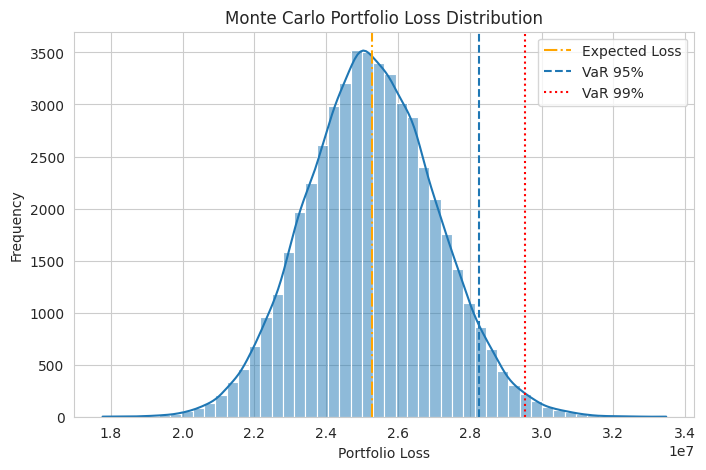

In [50]:

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

plt.figure(figsize=(8,5))

sns.histplot(portfolio_losses, bins=50, kde=True)

plt.axvline(expected_loss, linestyle='-.', label='Expected Loss',color="orange")
plt.axvline(var95, linestyle='--', label='VaR 95%')
plt.axvline(var99, linestyle=':', label='VaR 99%',color="red")

plt.title("Monte Carlo Portfolio Loss Distribution")
plt.xlabel("Portfolio Loss")
plt.ylabel("Frequency")

plt.legend()

plt.show()

Scenario analysis

In [51]:
scenarios = {
    "Baseline": 1.0,
    "Adverse": 1.3,
    "Severe": 1.6,
    "Crisis": 2.0
}

In [52]:
for scenario, stress in scenarios.items():
    df[f"PD_{scenario}"] = df["PD_base"] * stress

In [53]:
df[f"PD_{scenario}"] = df[f"PD_{scenario}"].clip(upper=1)

Running monte carlo simulations 

In [54]:

def simulate_losses(pd_column, simulations=50000):
    
    losses = []
    
    for _ in range(simulations):
        
        defaults = np.random.binomial(1, df[pd_column])
        
        loss = np.sum(
            defaults * df["Loan_Amount"] * df["LGD"]
        )
        
        losses.append(loss)
    
    return np.array(losses)

In [55]:
baseline_losses = simulate_losses("PD_Baseline")
adverse_losses = simulate_losses("PD_Adverse")
severe_losses = simulate_losses("PD_Severe")
crisis_losses = simulate_losses("PD_Crisis")

In [56]:

print("Baseline EL:", baseline_losses.mean())
print("Adverse EL:", adverse_losses.mean())
print("Severe EL:", severe_losses.mean())
print("Crisis EL:", crisis_losses.mean())

Baseline EL: 11197796.936876457
Adverse EL: 14570379.218506683
Severe EL: 17915783.737550333
Crisis EL: 22392946.203175176


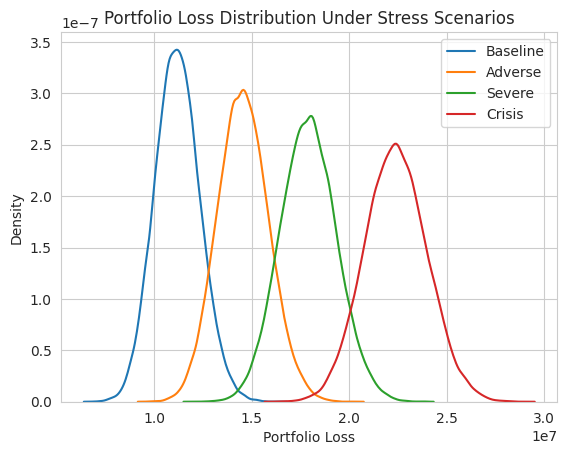

In [57]:
sns.kdeplot(baseline_losses, label="Baseline")
sns.kdeplot(adverse_losses, label="Adverse")
sns.kdeplot(severe_losses, label="Severe")
sns.kdeplot(crisis_losses, label="Crisis")

plt.title("Portfolio Loss Distribution Under Stress Scenarios")
plt.xlabel("Portfolio Loss")
plt.legend()

plt.show()

Macro shock scenario

at crisis the unemployment shock is 5%

In [58]:
macro_scenarios = {
    "Baseline": 0,
    "Adverse": 1.5,
    "Severe": 3.0,
    "Crisis": 5.0
}

In [59]:
beta = 0.35

In [60]:

for scenario, shock in macro_scenarios.items():
    
    df[f"PD_{scenario}"] = df["PD_base"] * np.exp(beta * shock)
    
    df[f"PD_{scenario}"] = df[f"PD_{scenario}"].clip(upper=1)

In [62]:
def simulate_losses(pd_column, simulations=50000):

    losses = []

    for _ in range(simulations):

        defaults = np.random.binomial(1, df[pd_column])

        loss = np.sum(defaults * df["Loan_Amount"] * df["LGD"])

        losses.append(loss)

    return np.array(losses)

In [64]:
baseline_losses = simulate_losses("PD_Baseline")
adverse_losses = simulate_losses("PD_Adverse")
severe_losses = simulate_losses("PD_Severe")
crisis_losses = simulate_losses("PD_Crisis")

In [65]:
print("Baseline EL:", baseline_losses.mean())
print("Adverse EL:", adverse_losses.mean())
print("Severe EL:", severe_losses.mean())
print("Crisis EL:", crisis_losses.mean())

Baseline EL: 11200618.790844547
Adverse EL: 18929403.01603847
Severe EL: 32010279.65552558
Crisis EL: 64444417.29936527


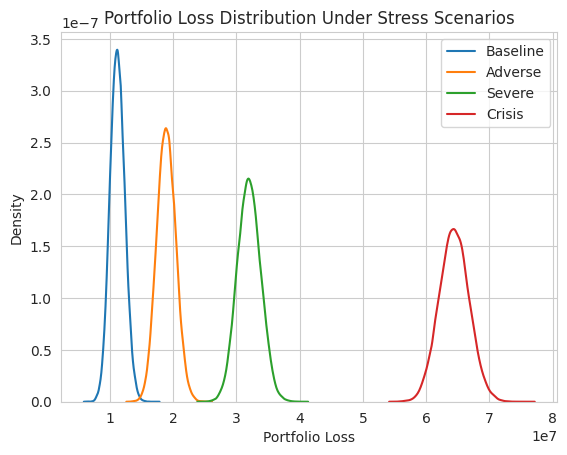

In [66]:


sns.kdeplot(baseline_losses, label="Baseline")
sns.kdeplot(adverse_losses, label="Adverse")
sns.kdeplot(severe_losses, label="Severe")
sns.kdeplot(crisis_losses, label="Crisis")

plt.title("Portfolio Loss Distribution Under Stress Scenarios")
plt.xlabel("Portfolio Loss")
plt.legend()

plt.show()